## Table of Contents

- [Introduction](#Introduction)
- [Data Loading](#Data-Loading)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Predictive Modeling](#Predictive-Modeling)
- [Conclusion](#Conclusion)

## Introduction

A curious mind would wonder how temperature, wind, precipitation and humidity interact to decide whether rain will grace the day. In this notebook, we explore a comprehensive dataset from Vietnam that includes weather details for weather enthusiasts and data scientists alike. Let us begin our expedition into the climatic variables and see if we can predict a rainy day.

In [7]:
# Suppress warnings and import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # If only plt is imported
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

# Set a style for seaborn
sns.set(style='whitegrid')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Data Loading

We start by reading in the weather dataset. The data contains a variety of meteorological variables including temperature, humidity, precipitation and more. Note that the `date` column is provided as a string and will be converted into a datetime object in the preprocessing step.

In [10]:
# Load the weather dataset from the local directory
df = pd.read_csv('/kaggle/input/dataset-weather-vit-nam-trong-1-nm-li/df_weather.csv', encoding='utf-8')

# Display the first few rows to check the data format
df.head()

,location.name,location.region,location.terrain,location.country,location.lat,location.lon,date,date_epoch,day.maxtemp_c,day.maxtemp_f,...,day.condition.text,day.condition.icon,day.condition.code,day.uv,astro.sunrise,astro.sunset,astro.moonrise,astro.moonset,astro.moon_phase,astro.moon_illumination
0,An Giang,Đồng Bằng Sông Cửu Long,đồng bằng,Vietnam,10.7000,105.1167,2024-04-21,1713657600,38.6,101.5,...,Sunny,//cdn.weatherapi.com/weather/64x64/day/113.png,1000,9.0,05:46 AM,06:11 PM,04:13 PM,03:55 AM,Waxing Gibbous,90
1,Bà Rịa-Vũng Tàu,Đông Nam Bộ,ven biển,Vietnam,10.3500,107.0667,2024-04-21,1713657600,30.2,86.3,...,Moderate rain at times,//cdn.weatherapi.com/weather/64x64/day/299.png,1186,7.0,05:38 AM,06:03 PM,04:05 PM,03:47 AM,Waxing Gibbous,90
2,Bắc Giang,Trung du và miền núi Bắc Bộ,miền núi,Vietnam,21.2667,106.2000,2024-04-21,1713657600,31.9,89.4,...,Heavy rain at times,//cdn.weatherapi.com/weather/64x64/day/305.png,1192,7.0,05:32 AM,06:16 PM,04:09 PM,03:53 AM,Waxing Gibbous,90
3,Bắc Kạn,Trung du và miền núi Bắc Bộ,miền núi,Vietnam,22.1333,105.8333,2024-04-21,1713657600,28.0,82.5,...,Moderate or heavy rain shower,//cdn.weatherapi.com/weather/64x64/day/356.png,1243,6.0,05:32 AM,06:19 PM,04:10 PM,03:54 AM,Waxing Gibbous,90
4,Bạc Liêu,Đồng Bằng Sông Cửu Long,ven biển,Vietnam,9.2850,105.7244,2024-04-21,1713657600,36.1,97.1,...,Partly cloudy,//cdn.weatherapi.com/weather/64x64/day/116.png,1003,9.0,05:45 AM,06:07 PM,04:11 PM,03:52 AM,Waxing Gibbous,90


In [12]:
output_path = '/kaggle/working/cleaned_weather_data.csv'
# Lưu file (thêm index=False để không bị dư cột số thứ tự của Pandas)
df.to_csv(output_path, index=False, encoding='utf-8')

print("Đã lưu file thành công vào:", output_path)

Đã lưu file thành công vào: /kaggle/working/cleaned_weather_data.csv


## Data Cleaning and Preprocessing

Before diving into analysis, we tidy the dataset. This includes converting the `date` column to a datetime format, checking for missing values, and ensuring that numeric columns are indeed in numeric format. This step is crucial because most of the visualization and predictive methods require perfectly formatted data. In my experience, this step is the unsung hero of data science.

In [13]:
# Convert 'date' column from string to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check for missing values and basic info about dataframe
print(df.info())

# Optionally, drop rows with missing essential values
df.dropna(subset=['day.maxtemp_c', 'day.mintemp_c', 'day.avgtemp_c', 'day.daily_will_it_rain'], inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26018 entries, 0 to 26017
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   location.name             26018 non-null  object        
 1   location.region           26018 non-null  object        
 2   location.terrain          26018 non-null  object        
 3   location.country          26018 non-null  object        
 4   location.lat              26018 non-null  float64       
 5   location.lon              26018 non-null  float64       
 6   date                      26018 non-null  datetime64[ns]
 7   date_epoch                26018 non-null  int64         
 8   day.maxtemp_c             26018 non-null  float64       
 9   day.maxtemp_f             26018 non-null  float64       
 10  day.mintemp_c             26018 non-null  float64       
 11  day.mintemp_f             26018 non-null  float64       
 12  day.avgtemp_c     

## Exploratory Data Analysis

The exploratory analysis section uses several visual techniques to uncover patterns. We will produce a correlation heatmap (limited to numeric columns), a pair plot for key temperature and humidity variables, a histogram for maximum temperature, and a count plot for our binary rain indicator. Each visualization method provides a glimpse into the subtle interactions in the data.

Note: If any visualization throws an error due to data format issues, ensure the data cleaning steps above are properly executed.

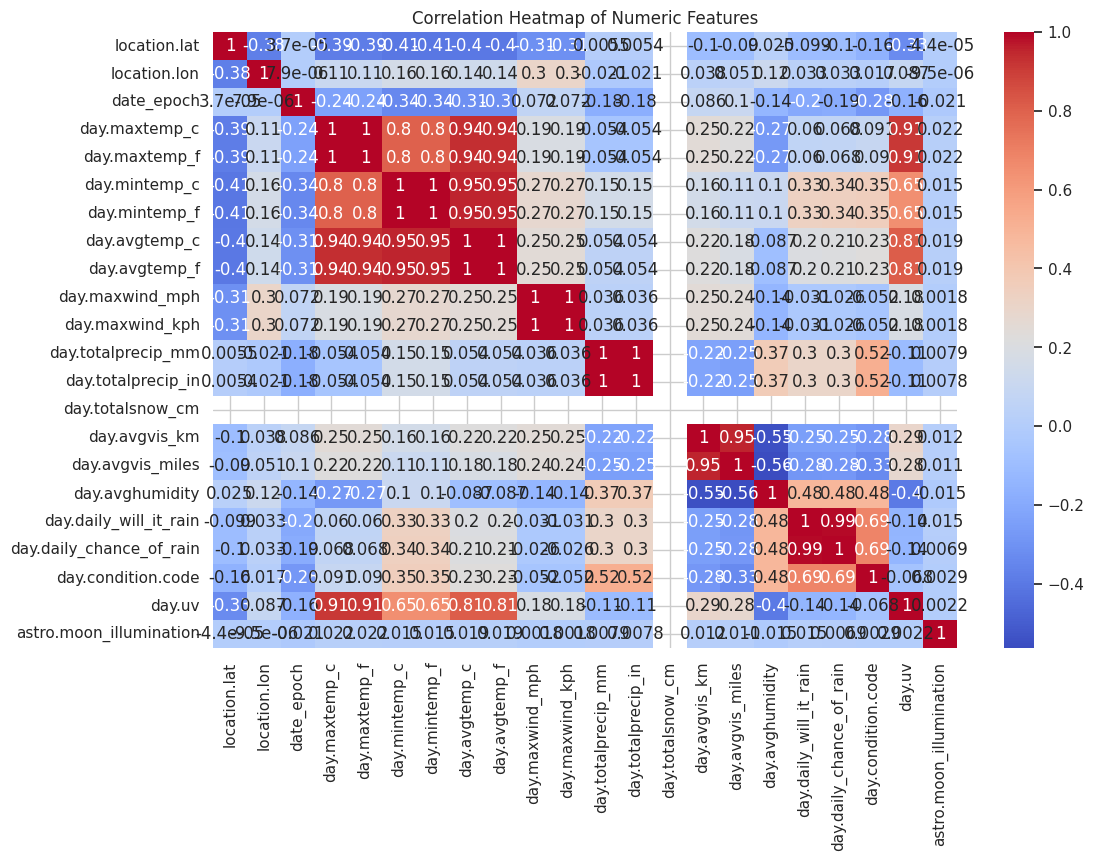

In [23]:
# Correlation Heatmap for numeric features if there are four or more numeric columns
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.savefig('heatmap_corr.png')
    plt.show()
    plt.close()



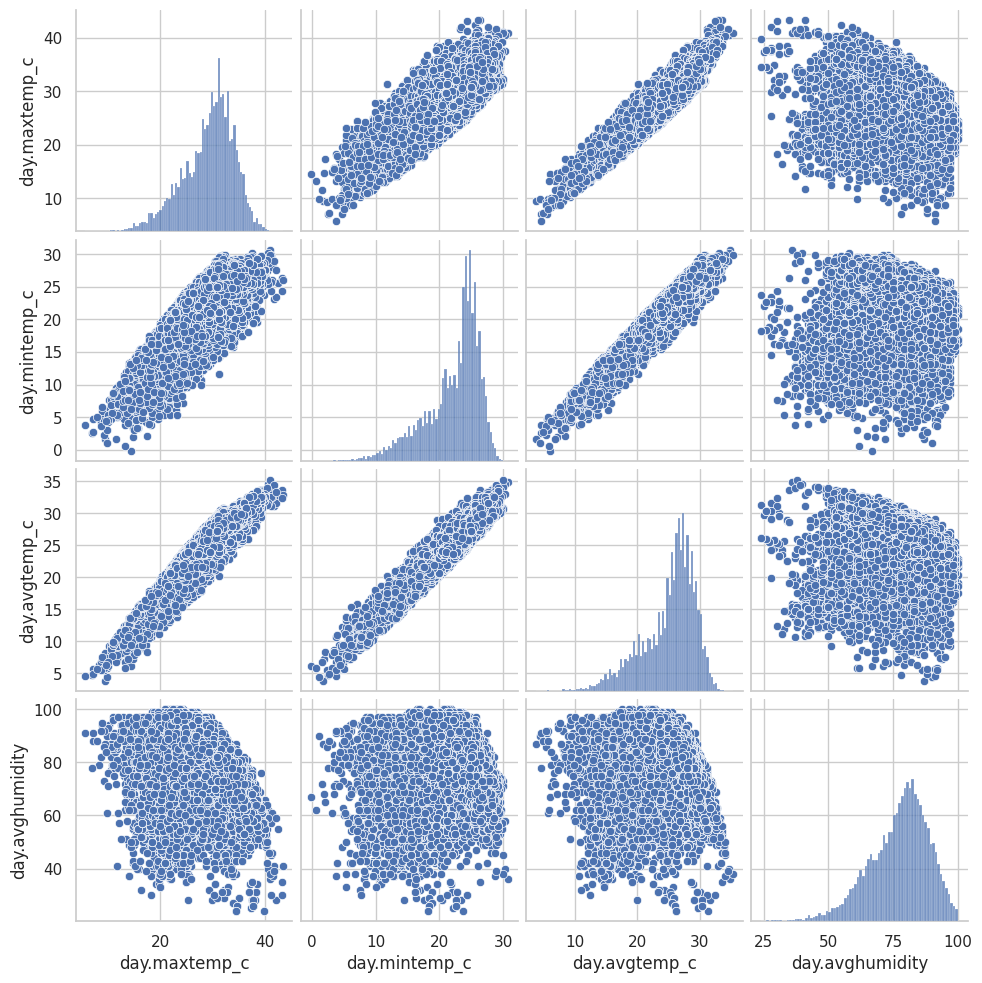

In [24]:
# Pair plot for a subset of continuous variables
subset_cols = ['day.maxtemp_c', 'day.mintemp_c', 'day.avgtemp_c', 'day.avghumidity']
sns.pairplot(df[subset_cols].dropna())
plt.savefig('pairplot.png')
plt.show()


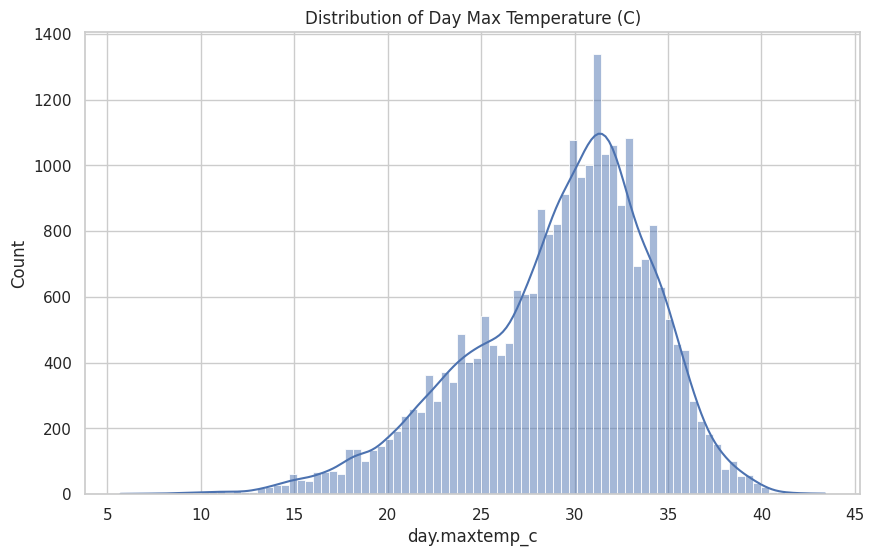

In [25]:

# Histogram for maximum temperature (C)
plt.figure(figsize=(10, 6))
sns.histplot(df['day.maxtemp_c'], kde=True)
plt.title('Distribution of Day Max Temperature (C)')
plt.savefig('histogram_maxtemp_c.png')
plt.show()


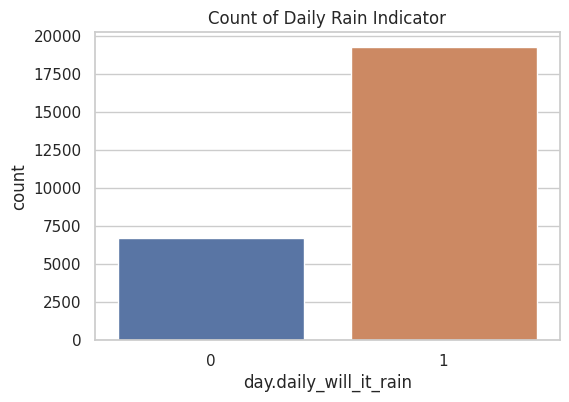

In [26]:

# Count plot for the daily rain indicator
plt.figure(figsize=(6, 4))
sns.countplot(x='day.daily_will_it_rain', data=df)
plt.title('Count of Daily Rain Indicator')
plt.savefig('countplot_daily_rain.png')
plt.show()

## Predictive Modeling

It is time to play the role of a meteorologist-cum-data scientist. In this section, a predictor is built to estimate whether it will rain on a given day using a Random Forest classifier. We select a few numeric features such as the average temperature, maximum wind speed, precipitation, humidity, and UV index. The model's performance is judged by the accuracy score, confusion matrix and the ROC curve with computed AUC. If any issues arise during model training or evaluation, these steps should help diagnose and prevent similar errors for other users.

Random Forest à một thuật toán học máy (Machine Learning) thuộc nhóm Ensemble Learning (Học kết hợp), nổi tiếng với độ chính xác cao và khả năng chống overfitting rất tốt. Thuật toán này có thể dùng cho cả bài toán phân loại (Classification) như dự đoán trời mưa hay không và hồi quy (Regression).

Bản chất của thuật toán này nằm ngay trong tên gọi: xây dựng một "khu rừng" bao gồm nhiều "cây quyết định" (Decision Trees) và tổng hợp kết quả của chúng lại.
<image> <>

Dưới đây là các nền tảng lý thuyết cốt lõi tạo nên sức mạnh của Random Forest:

1. Triết lý "Trí tuệ đám đông" (Ensemble Learning)

Một cây quyết định (Decision Tree) đơn lẻ thường rất dễ bị học vẹt (overfit) vào dữ liệu huấn luyện – tức là nó chia nhánh quá chi tiết, dẫn đến dự đoán kém trên dữ liệu mới.
Random Forest giải quyết điều này bằng cách tạo ra hàng trăm, hàng ngàn cây quyết định độc lập. Mỗi cây sẽ đưa ra một dự đoán riêng.

Với bài toán phân loại: Kết quả cuối cùng là kết quả được nhiều cây "bầu chọn" nhất (Majority Voting).

Với bài toán hồi quy: Kết quả cuối cùng là trung bình cộng dự đoán của tất cả các cây.

2. Hai kỹ thuật khử tương quan (Decoupling Techniques)

Để đảm bảo các cây trong rừng không bị giống hệt nhau (nếu giống nhau thì việc gom lại vô nghĩa), Random Forest áp dụng hai mức độ ngẫu nhiên:

Kỹ thuật Bagging (Bootstrap Aggregating): Thay vì huấn luyện mọi cây trên cùng một bộ dữ liệu ban đầu D có kích thước N, mô hình sẽ tạo ra các tập con Di bằng cách bốc thăm ngẫu nhiên có hoàn lại (random sampling with replacement) từ D. Mỗi tập con Di cũng có kích thước N nhưng sẽ có những mẫu dữ liệu bị lặp lại và có khoảng 37% dữ liệu ban đầu không xuất hiện trong Di (gọi là dữ liệu Out-Of-Bag - OOB). Mỗi cây sẽ được huấn luyện trên một tập Di khác nhau.

Tính ngẫu nhiên của đặc trưng (Feature Randomness): Trong một cây quyết định thông thường, tại mỗi nút (node), thuật toán sẽ quét qua toàn bộ M đặc trưng (features) để tìm ra đặc trưng chia nhánh tốt nhất. Nhưng trong Random Forest, tại mỗi nút, mô hình chỉ chọn ngẫu nhiên một tập con gồm m đặc trưng (thường m≈M đối với bài toán phân loại). Điều này ép các cây phải khai thác cả những đặc trưng yếu hơn, giúp các cây trong rừng hoàn toàn khác biệt nhau (uncorrelated).

3. Ưu điểm và Nhược điểm

* Ưu điểm:

* *  Chống Overfitting: Nhờ Bagging và Feature Randomness, mô hình kiểm soát nhiễu rất tốt.

* * Xử lý dữ liệu thiếu / Mất cân bằng: Hoạt động ổn định ngay cả khi dữ liệu bị khuyết hoặc các lớp không đồng đều.

* * Đo lường tầm quan trọng (Feature Importance): Cung cấp độ đo trực quan xem đặc trưng nào (ví dụ: nhiệt độ hay độ ẩm) đóng góp nhiều nhất vào việc phân loại.

* Nhược điểm:

* * Hộp đen (Black-box): Rất khó để giải thích cặn kẽ đường đi của dữ liệu như một cây quyết định đơn lẻ.

* * Tốn kém tài nguyên: Huấn luyện hàng trăm cây tốn nhiều bộ nhớ và thời gian dự đoán (inference) chậm hơn so với các mô hình tuyến tính.

**Bài toán:**
Một hàm số f(X)=y. Trong đó:

X (Features): Nhiệt độ, độ ẩm, sức gió, lượng mưa, UV... của một ngày cụ thể.

y (Target): Ngày hôm đó có mưa hay không (1 hoặc 0).

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# 1. Chuẩn bị dữ liệu (Feature Selection)
# Chọn các đặc trưng theo đúng yêu cầu: nhiệt độ TB, gió max, lượng mưa, độ ẩm, UV
features = ['day.avgtemp_c', 'day.maxwind_kph', 'day.totalprecip_mm', 'day.avghumidity', 'day.uv']
target = 'day.daily_will_it_rain'

# Lọc bỏ các dòng có giá trị NaN để model không bị lỗi
model_data = df[features + [target]].dropna()

X = model_data[features]
y = model_data[target]

# 2. Chia tập dữ liệu Train / Test (Tỉ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Khởi tạo và Huấn luyện mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [17]:
# 4. Dự đoán và Đánh giá sơ bộ
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # Lấy xác suất của class 1 (Trời mưa)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")


Accuracy Score: 0.9996


Đã lưu biểu đồ Confusion Matrix thành 'confusion_matrix_rf.png'


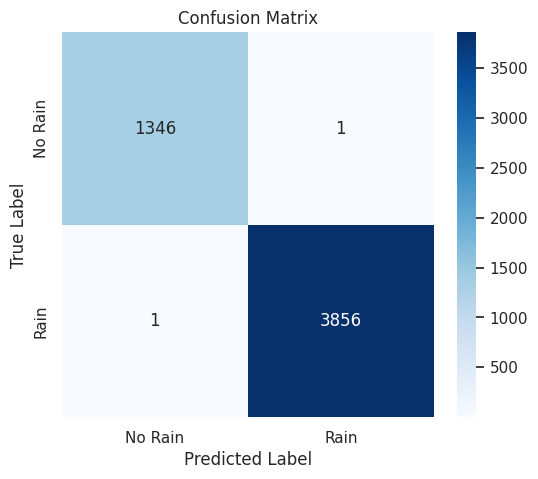

In [19]:

# 5. Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_rf.png') 
print("Đã lưu biểu đồ Confusion Matrix thành 'confusion_matrix_rf.png'")
plt.show()

Đã lưu biểu đồ ROC Curve thành 'roc_curve_rf.png'


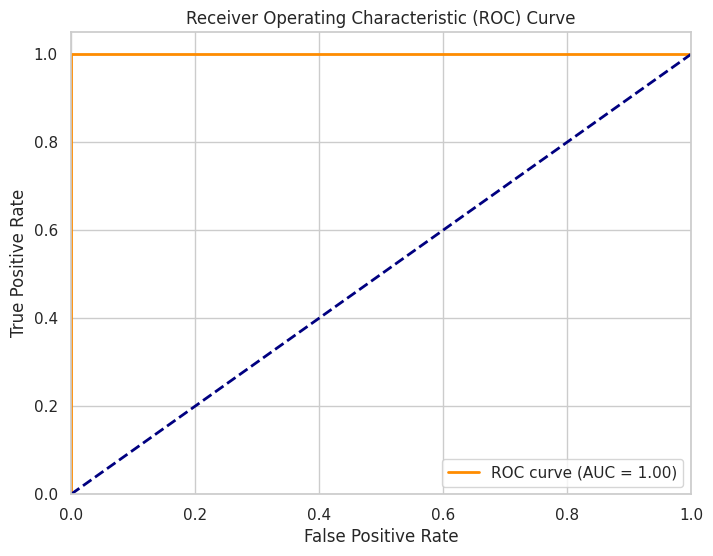

In [20]:

# 6. Vẽ ROC Curve và tính AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_curve_rf.png') 
print("Đã lưu biểu đồ ROC Curve thành 'roc_curve_rf.png'")
plt.show()

In [21]:
import pandas as pd

# Giả sử muốn dự đoán thời tiết cho một ngày cụ thể, 
# Nhập các thông số vào đúng theo thứ tự features đã dùng để train:
# ['day.avgtemp_c', 'day.maxwind_kph', 'day.totalprecip_mm', 'day.avghumidity', 'day.uv']

test_data = pd.DataFrame({
    'day.avgtemp_c': [32.5],       # Nhiệt độ trung bình 32.5 C
    'day.maxwind_kph': [12.0],     # Tốc độ gió max 12 km/h
    'day.totalprecip_mm': [5.2],   # Lượng mưa 5.2 mm (dấu hiệu có mưa)
    'day.avghumidity': [85.0],     # Độ ẩm cao 85%
    'day.uv': [4.0]                # UV mức 4
})

# Gọi mô hình để dự đoán (0: No Rain, 1: Rain)
prediction = rf_model.predict(test_data)

# Lấy xác suất tự tin của mô hình
probabilities = rf_model.predict_proba(test_data)[0]

print("--- KẾT QUẢ TEST MÔ HÌNH ---")
if prediction[0] == 1:
    print(f"Dự đoán: TRỜI SẼ MƯA 🌧️")
    print(f"Mô hình tự tin: {probabilities[1]*100:.2f}%")
else:
    print(f"Dự đoán: TRỜI KHÔNG MƯA ☀️")
    print(f"Mô hình tự tin: {probabilities[0]*100:.2f}%")

--- KẾT QUẢ TEST MÔ HÌNH ---
Dự đoán: TRỜI SẼ MƯA 🌧️
Mô hình tự tin: 98.00%
